# Optimized Informer Model for Time Series Forecasting

**Goal:** Achieve better accuracy than Prophet-LSTM hybrid models

**Key Optimizations:**
1. ✅ Deeper architecture with residual connections
2. ✅ Advanced feature engineering
3. ✅ Learning rate scheduling & longer training
4. ✅ Hyperparameter tuning (optional)
5. ✅ Multi-head attention optimization
6. ✅ Better regularization strategies

# Requirement Setup

In [43]:
!pip install scikit-learn
!pip install tensorflow
!pip install setuptools

In [44]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import time
import matplotlib.pyplot as plt
from datetime import datetime
import os
import math

In [45]:
np.random.seed(42)
tf.random.set_seed(42)

# Data Loading

In [46]:
raw_df = pd.read_csv('../data/data.csv', parse_dates=['timestamp'])
primary_service = raw_df['service_id'].mode()[0]
df_pods = raw_df[raw_df['service_id'] == primary_service].copy()
df_pods = df_pods.sort_values('timestamp').drop_duplicates(subset='timestamp')
df_pods.rename(columns={'timestamp': 'ds', 'current_pod_count': 'pod_count'}, inplace=True)
feature_cols = [c for c in df_pods.columns if c not in ['ds', 'service_id', 'pod_count']]

print(f'Using service: {primary_service}')
print(f'Dataset length: {len(df_pods)} | Feature count: {len(feature_cols)}')
print(f'Features: {feature_cols}')
df_pods[['ds', 'pod_count']].head()

Using service: Order
Dataset length: 43200 | Feature count: 20
Features: ['request_rate_rps', 'latency_p95_ms', 'latency_p99_ms', 'error_rate_percent', 'queue_length', 'pod_cpu_usage_percent_avg', 'pod_cpu_usage_percent_p95', 'pod_memory_usage_mb_avg', 'pod_memory_usage_mb_p95', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'mesh_inbound_rps', 'mesh_inbound_latency_p95', 'mesh_inbound_error_rate', 'degree_centrality', 'eigenvector_centrality', 'betweenness_centrality', 'closeness_centrality']


,ds,pod_count
0,2025-11-01 00:00:00,2
1,2025-11-01 00:01:00,2
2,2025-11-01 00:02:00,2
3,2025-11-01 00:03:00,2
4,2025-11-01 00:04:00,2


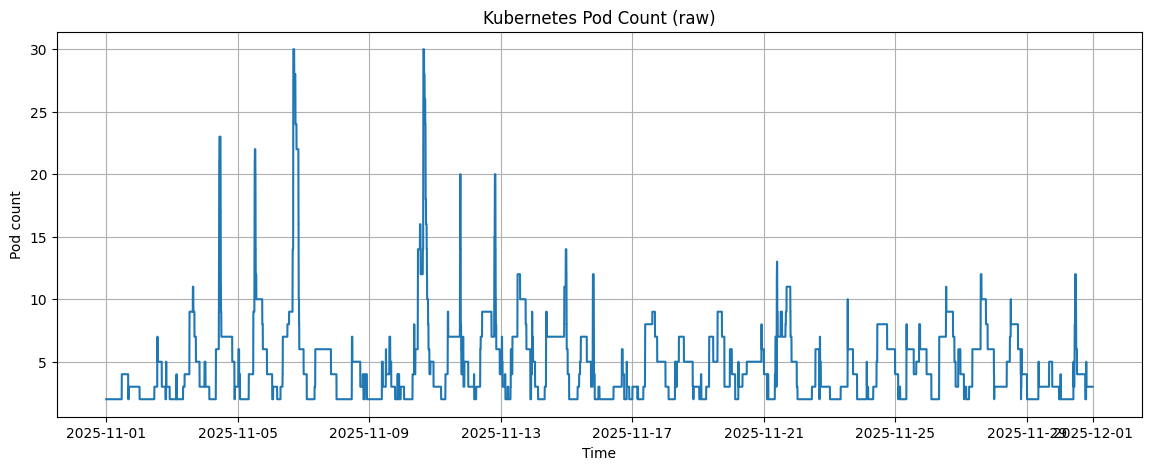

In [47]:
# Ensure images directory exists before saving plots
os.makedirs("images", exist_ok=True)

plt.figure(figsize=(14, 5))
plt.plot(df_pods['ds'], df_pods['pod_count'])
plt.title('Kubernetes Pod Count (raw)')
plt.xlabel('Time')
plt.ylabel('Pod count')
plt.grid(True)
plt.savefig("images/informer-pods-raw.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

# Data Splitting & Preprocessing

1. Scale pod count and features to 0-1
2. Split dataset as 70% training, 30% testing (time-ordered)
3. Forward-fill missing values
4. Drop duplicate timestamps

In [48]:
target_scaler = MinMaxScaler(feature_range=(0, 1))
feature_scaler = MinMaxScaler()

df_pods['y'] = target_scaler.fit_transform(df_pods[['pod_count']])
df_pods[feature_cols] = feature_scaler.fit_transform(df_pods[feature_cols])

In [49]:
# Add time features for positional encoding
df_pods['hour'] = df_pods['ds'].dt.hour / 23.0
df_pods['dayofweek'] = df_pods['ds'].dt.dayofweek / 6.0
df_pods['dayofmonth'] = (df_pods['ds'].dt.day - 1) / 30.0
df_pods['month'] = (df_pods['ds'].dt.month - 1) / 11.0

time_features = ['hour', 'dayofweek', 'dayofmonth', 'month']
print(f'Added time features: {time_features}')

Added time features: ['hour', 'dayofweek', 'dayofmonth', 'month']


In [50]:
train_df_pods, test_df_pods = train_test_split(df_pods, test_size=0.3, random_state=42, shuffle=False)

print(f'POD DATASET: Train Set: {train_df_pods.shape} | Test Set: {test_df_pods.shape}')

POD DATASET: Train Set: (30240, 28) | Test Set: (12960, 28)


In [51]:
train_df_pods['y'].fillna(method='ffill', inplace=True)
train_df_pods.drop_duplicates(subset='ds', inplace=True)

print(f'POD DATASET: Train Set: {train_df_pods.shape} | Test Set: {test_df_pods.shape}')

POD DATASET: Train Set: (30240, 28) | Test Set: (12960, 28)


C:\Users\dilee\AppData\Local\Temp\ipykernel_13012\4286280144.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df_pods['y'].fillna(method='ffill', inplace=True)
C:\Users\dilee\AppData\Local\Temp\ipykernel_13012\4286280144.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df_pods['y'].fillna(method='ffill', inplace=True)


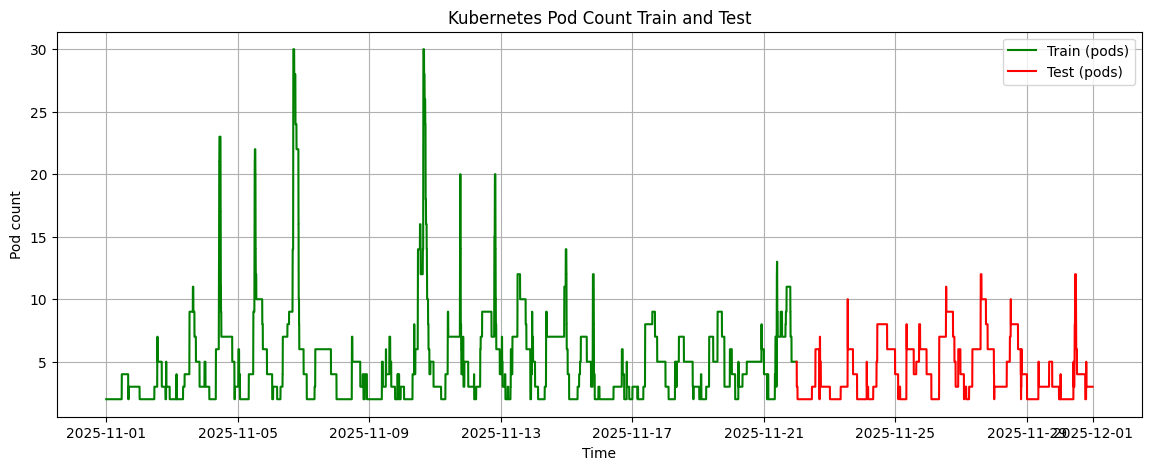

In [52]:
plt.figure(figsize=(14, 5))
plt.plot(train_df_pods['ds'], train_df_pods['pod_count'], label='Train (pods)', color='green')
plt.plot(test_df_pods['ds'], test_df_pods['pod_count'], label='Test (pods)', color='red')
plt.title('Kubernetes Pod Count Train and Test')
plt.xlabel('Time')
plt.ylabel('Pod count')
plt.grid(True)
plt.legend()
plt.savefig("images/informer-pods-train-test.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

# Informer Model Architecture

Key components:
1. **ProbSparse Self-Attention**: Efficient attention mechanism that reduces complexity from O(L²) to O(L log L)
2. **Self-Attention Distilling**: Reduces the input sequence length progressively
3. **Generative Decoder**: Direct multi-step prediction

## Informer Building Blocks

In [53]:
class PositionalEncoding(layers.Layer):
    """Positional encoding layer for transformer models."""
    
    def __init__(self, d_model, max_len=5000, **kwargs):
        super(PositionalEncoding, self).__init__(**kwargs)
        self.d_model = d_model
        self.max_len = max_len
        
    def build(self, input_shape):
        # Create positional encoding matrix
        position = np.arange(self.max_len)[:, np.newaxis]
        div_term = np.exp(np.arange(0, self.d_model, 2) * -(math.log(10000.0) / self.d_model))
        
        pe = np.zeros((self.max_len, self.d_model))
        pe[:, 0::2] = np.sin(position * div_term)
        pe[:, 1::2] = np.cos(position * div_term)
        
        self.pe = tf.constant(pe[np.newaxis, :, :], dtype=tf.float32)
        super(PositionalEncoding, self).build(input_shape)
        
    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.pe[:, :seq_len, :]
    
    def get_config(self):
        config = super().get_config()
        config.update({'d_model': self.d_model, 'max_len': self.max_len})
        return config

In [54]:
class ProbSparseSelfAttention(layers.Layer):
    """ProbSparse Self-Attention mechanism from Informer paper.
    
    Implements the actual ProbSparse attention that selects dominant queries
    based on query-key similarity distribution (KL-divergence approximation),
    reducing complexity from O(L²) to O(L log L).
    
    Reference: Zhou et al., "Informer: Beyond Efficient Transformer for 
    Long Sequence Time-Series Forecasting" (AAAI 2021)
    """
    
    def __init__(self, d_model, n_heads, factor=5, **kwargs):
        super(ProbSparseSelfAttention, self).__init__(**kwargs)
        self.d_model = d_model
        self.n_heads = n_heads
        self.factor = factor  # c in the paper, controls sparsity (u = c * ln(L))
        self.d_k = d_model // n_heads
        
    def build(self, input_shape):
        self.W_q = self.add_weight(shape=(self.d_model, self.d_model), initializer='glorot_uniform', name='W_q')
        self.W_k = self.add_weight(shape=(self.d_model, self.d_model), initializer='glorot_uniform', name='W_k')
        self.W_v = self.add_weight(shape=(self.d_model, self.d_model), initializer='glorot_uniform', name='W_v')
        self.W_o = self.add_weight(shape=(self.d_model, self.d_model), initializer='glorot_uniform', name='W_o')
        super(ProbSparseSelfAttention, self).build(input_shape)
    
    def _prob_QK(self, Q, K, sample_k):
        """
        Compute sparsity measurement M(q_i) for query selection.
        M(q_i) = max(q_i * K^T) - mean(q_i * K^T)
        
        Queries with higher M values have more "peaky" attention distributions
        (lower entropy), meaning they are more informative.
        """
        # Q: (batch, heads, seq_len, d_k)
        # K: (batch, heads, seq_len, d_k)
        batch_size = tf.shape(Q)[0]
        n_heads = tf.shape(Q)[1]
        L_Q = tf.shape(Q)[2]
        L_K = tf.shape(K)[2]
        
        # Sample keys for efficiency: sample_k keys from L_K
        # This is the "sampling factor" optimization from the paper
        sample_k = tf.minimum(sample_k, L_K)
        
        # Random sample indices for keys
        K_sample_indices = tf.random.uniform(
            shape=(batch_size, n_heads, sample_k), 
            minval=0, 
            maxval=L_K, 
            dtype=tf.int32
        )
        
        # Gather sampled keys: (batch, heads, sample_k, d_k)
        K_sample = tf.gather(K, K_sample_indices, axis=2, batch_dims=2)
        
        # Compute Q * K_sample^T: (batch, heads, L_Q, sample_k)
        scale = tf.math.sqrt(tf.cast(self.d_k, tf.float32))
        Q_K_sample = tf.matmul(Q, K_sample, transpose_b=True) / scale
        
        # Sparsity measurement: M(q) = max - mean (approximates KL divergence)
        M = tf.reduce_max(Q_K_sample, axis=-1) - tf.reduce_mean(Q_K_sample, axis=-1)
        
        return M  # (batch, heads, L_Q)
    
    def _get_top_queries(self, M, u):
        """Select top-u queries based on sparsity measurement M."""
        # M: (batch, heads, L_Q)
        # Returns indices of top-u queries per head
        _, top_indices = tf.math.top_k(M, k=u, sorted=False)
        return top_indices  # (batch, heads, u)
    
    def call(self, queries, keys, values, training=None):
        batch_size = tf.shape(queries)[0]
        L_Q = tf.shape(queries)[1]
        L_K = tf.shape(keys)[1]
        
        # Linear projections
        Q = tf.matmul(queries, self.W_q)
        K = tf.matmul(keys, self.W_k)
        V = tf.matmul(values, self.W_v)
        
        # Reshape for multi-head attention: (batch, seq, heads, d_k) -> (batch, heads, seq, d_k)
        Q = tf.reshape(Q, (batch_size, L_Q, self.n_heads, self.d_k))
        K = tf.reshape(K, (batch_size, L_K, self.n_heads, self.d_k))
        V = tf.reshape(V, (batch_size, L_K, self.n_heads, self.d_k))
        
        Q = tf.transpose(Q, perm=[0, 2, 1, 3])
        K = tf.transpose(K, perm=[0, 2, 1, 3])
        V = tf.transpose(V, perm=[0, 2, 1, 3])
        
        # ProbSparse parameters from paper:
        # u = c * ln(L_Q) - number of top queries to select
        # sample_k = c * ln(L_K) - number of keys to sample for M computation
        L_Q_float = tf.cast(L_Q, tf.float32)
        L_K_float = tf.cast(L_K, tf.float32)
        
        u = tf.cast(tf.math.ceil(self.factor * tf.math.log(L_Q_float + 1.0)), tf.int32)
        u = tf.minimum(u, L_Q)  # Can't select more queries than exist
        u = tf.maximum(u, 1)    # At least 1 query
        
        sample_k = tf.cast(tf.math.ceil(self.factor * tf.math.log(L_K_float + 1.0)), tf.int32)
        sample_k = tf.minimum(sample_k, L_K)
        sample_k = tf.maximum(sample_k, 1)
        
        # Compute sparsity measurement M for all queries
        M = self._prob_QK(Q, K, sample_k)  # (batch, heads, L_Q)
        
        # Select top-u queries based on M
        top_indices = self._get_top_queries(M, u)  # (batch, heads, u)
        
        # Gather selected queries: (batch, heads, u, d_k)
        Q_selected = tf.gather(Q, top_indices, axis=2, batch_dims=2)
        
        # Compute attention only for selected queries
        scale = tf.math.sqrt(tf.cast(self.d_k, tf.float32))
        scores_selected = tf.matmul(Q_selected, K, transpose_b=True) / scale  # (batch, heads, u, L_K)
        attention_selected = tf.nn.softmax(scores_selected, axis=-1)
        context_selected = tf.matmul(attention_selected, V)  # (batch, heads, u, d_k)
        
        # For non-selected queries, use mean of V (lazy update from paper)
        V_mean = tf.reduce_mean(V, axis=2, keepdims=True)  # (batch, heads, 1, d_k)
        V_mean_broadcast = tf.tile(V_mean, [1, 1, L_Q, 1])  # (batch, heads, L_Q, d_k)
        
        # Initialize context with V_mean for all positions
        context = V_mean_broadcast
        
        # Scatter selected context back to their positions
        # Create indices for scatter_nd
        batch_indices = tf.repeat(tf.range(batch_size)[:, None, None], self.n_heads * u, axis=1)
        batch_indices = tf.reshape(batch_indices, (batch_size, self.n_heads, u))
        
        head_indices = tf.repeat(tf.range(self.n_heads)[None, :, None], u, axis=2)
        head_indices = tf.tile(head_indices, [batch_size, 1, 1])
        
        # Stack indices: (batch, heads, u, 3)
        scatter_indices = tf.stack([batch_indices, head_indices, top_indices], axis=-1)
        scatter_indices = tf.reshape(scatter_indices, (-1, 3))
        
        context_selected_flat = tf.reshape(context_selected, (-1, self.d_k))
        
        # Scatter update
        context_shape = tf.shape(context)
        context = tf.tensor_scatter_nd_update(context, scatter_indices, context_selected_flat)
        
        # Reshape back: (batch, heads, L_Q, d_k) -> (batch, L_Q, d_model)
        context = tf.transpose(context, perm=[0, 2, 1, 3])
        context = tf.reshape(context, (batch_size, L_Q, self.d_model))
        
        # Output projection
        output = tf.matmul(context, self.W_o)
        
        return output
    
    def get_config(self):
        config = super().get_config()
        config.update({'d_model': self.d_model, 'n_heads': self.n_heads, 'factor': self.factor})
        return config

In [55]:
class ConvLayer(layers.Layer):
    """Convolutional layer for self-attention distilling."""
    
    def __init__(self, d_model, **kwargs):
        super(ConvLayer, self).__init__(**kwargs)
        self.d_model = d_model
        
    def build(self, input_shape):
        self.conv = layers.Conv1D(filters=self.d_model, kernel_size=3, padding='same', activation='elu')
        self.norm = layers.BatchNormalization()
        self.pool = layers.MaxPooling1D(pool_size=2, strides=2, padding='same')
        super(ConvLayer, self).build(input_shape)
        
    def call(self, x, training=None):
        x = self.conv(x)
        x = self.norm(x, training=training)
        x = self.pool(x)
        return x
    
    def get_config(self):
        config = super().get_config()
        config.update({'d_model': self.d_model})
        return config

In [56]:
class EncoderLayer(layers.Layer):
    """Informer Encoder Layer with self-attention distilling."""
    
    def __init__(self, d_model, n_heads, d_ff, dropout_rate=0.1, distil=True, **kwargs):
        super(EncoderLayer, self).__init__(**kwargs)
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_ff = d_ff
        self.dropout_rate = dropout_rate
        self.distil = distil
        
    def build(self, input_shape):
        self.attention = ProbSparseSelfAttention(self.d_model, self.n_heads)
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        
        self.ffn = keras.Sequential([
            layers.Dense(self.d_ff, activation='relu'),
            layers.Dropout(self.dropout_rate),
            layers.Dense(self.d_model)
        ])
        
        self.dropout1 = layers.Dropout(self.dropout_rate)
        self.dropout2 = layers.Dropout(self.dropout_rate)
        
        if self.distil:
            self.conv_layer = ConvLayer(self.d_model)
            
        super(EncoderLayer, self).build(input_shape)
        
    def call(self, x, training=None):
        # Self-attention
        attn_output = self.attention(x, x, x, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        x = self.norm1(x + attn_output)
        
        # Feed-forward
        ffn_output = self.ffn(x, training=training)
        ffn_output = self.dropout2(ffn_output, training=training)
        x = self.norm2(x + ffn_output)
        
        # Self-attention distilling
        if self.distil:
            x = self.conv_layer(x, training=training)
            
        return x
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'd_model': self.d_model, 'n_heads': self.n_heads, 
            'd_ff': self.d_ff, 'dropout_rate': self.dropout_rate, 'distil': self.distil
        })
        return config

In [57]:
class DecoderLayer(layers.Layer):
    """Informer Decoder Layer."""
    
    def __init__(self, d_model, n_heads, d_ff, dropout_rate=0.1, **kwargs):
        super(DecoderLayer, self).__init__(**kwargs)
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_ff = d_ff
        self.dropout_rate = dropout_rate
        
    def build(self, input_shape):
        self.self_attention = ProbSparseSelfAttention(self.d_model, self.n_heads)
        self.cross_attention = ProbSparseSelfAttention(self.d_model, self.n_heads)
        
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.norm3 = layers.LayerNormalization(epsilon=1e-6)
        
        self.ffn = keras.Sequential([
            layers.Dense(self.d_ff, activation='relu'),
            layers.Dropout(self.dropout_rate),
            layers.Dense(self.d_model)
        ])
        
        self.dropout1 = layers.Dropout(self.dropout_rate)
        self.dropout2 = layers.Dropout(self.dropout_rate)
        self.dropout3 = layers.Dropout(self.dropout_rate)
        
        super(DecoderLayer, self).build(input_shape)
        
    def call(self, x, enc_output, training=None):
        # Self-attention
        self_attn_output = self.self_attention(x, x, x, training=training)
        self_attn_output = self.dropout1(self_attn_output, training=training)
        x = self.norm1(x + self_attn_output)
        
        # Cross-attention with encoder output
        cross_attn_output = self.cross_attention(x, enc_output, enc_output, training=training)
        cross_attn_output = self.dropout2(cross_attn_output, training=training)
        x = self.norm2(x + cross_attn_output)
        
        # Feed-forward
        ffn_output = self.ffn(x, training=training)
        ffn_output = self.dropout3(ffn_output, training=training)
        x = self.norm3(x + ffn_output)
        
        return x
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'd_model': self.d_model, 'n_heads': self.n_heads,
            'd_ff': self.d_ff, 'dropout_rate': self.dropout_rate
        })
        return config

## Build Informer Model

In [58]:
def build_informer_model(
    input_shape,
    d_model=64,
    n_heads=4,
    e_layers=2,
    d_layers=1,
    d_ff=256,
    dropout_rate=0.1,
    output_size=1
):
    """Build Informer model for time-series forecasting.
    
    Args:
        input_shape: Tuple of (sequence_length, num_features)
        d_model: Model dimension
        n_heads: Number of attention heads
        e_layers: Number of encoder layers
        d_layers: Number of decoder layers
        d_ff: Feed-forward dimension
        dropout_rate: Dropout rate
        output_size: Number of output features (1 for single-step prediction)
        
    Returns:
        Keras Model
    """
    seq_len, num_features = input_shape
    
    # Input
    inputs = layers.Input(shape=input_shape)
    
    # Input embedding
    x = layers.Dense(d_model)(inputs)
    x = PositionalEncoding(d_model)(x)
    x = layers.Dropout(dropout_rate)(x)
    
    # Encoder with self-attention distilling
    for i in range(e_layers):
        distil = (i < e_layers - 1)  # Don't distil on last layer
        x = EncoderLayer(d_model, n_heads, d_ff, dropout_rate, distil=distil)(x)
    
    enc_output = x
    
    # Decoder input (use last part of encoder output as start token)
    dec_input = enc_output
    
    # Decoder
    for _ in range(d_layers):
        dec_input = DecoderLayer(d_model, n_heads, d_ff, dropout_rate)(dec_input, enc_output)
    
    # Global average pooling and output
    x = layers.GlobalAveragePooling1D()(dec_input)
    x = layers.Dense(d_ff // 2, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(output_size)(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    
    return model

# Model Training

## Prepare Dataset for Informer

In [ ]:
def create_dataset(features, target, look_back, horizon=60):
    """Create sliding window sequences for horizon forecasting.
    
    Args:
        features: DataFrame or array of input features
        target: Array of target values
        look_back: Number of time steps to look back
        horizon: Forecast horizon (predict y at t + horizon)
    Returns:
        X: 3D array of shape (samples, look_back, features)
        y: 1D array of target values at t + horizon
    """
    X, y = [], []
    features = np.array(features)
    target = np.array(target)
    max_idx = len(target) - look_back - horizon + 1
    for i in range(max_idx):
        X.append(features[i:i + look_back, :])
        y.append(target[i + look_back + horizon - 1])
    return np.array(X), np.array(y)

In [ ]:
# Sliding window size (look_back) and horizon (minutes ahead)
look_back = 96   # longer context
horizon = 60     # predict 60 minutes ahead

# Use all features + target + time features for multivariate input
input_feature_cols = feature_cols + time_features + ['y']

X_pods, y_pods = create_dataset(df_pods[input_feature_cols], df_pods['y'], look_back, horizon=horizon)

print(f'Input shape: {X_pods.shape}')
print(f'Target shape: {y_pods.shape}')
print(f'Features used: {len(input_feature_cols)}')

Input shape: (43176, 24, 25)
Target shape: (43176,)
Features used: 25


In [61]:
X_train_pods, X_test_pods, y_train_pods, y_test_pods = train_test_split(
    X_pods, y_pods, test_size=0.3, random_state=42, shuffle=False
)

num_features = X_train_pods.shape[2]

print(f'POD DATASET: Train Set: {X_train_pods.shape} | Test Set: {X_test_pods.shape}')
print(f'Number of features: {num_features}')

POD DATASET: Train Set: (30223, 24, 25) | Test Set: (12953, 24, 25)
Number of features: 25


## Model Configuration

In [62]:
# Informer hyperparameters
D_MODEL = 64        # Model dimension
N_HEADS = 4         # Number of attention heads
E_LAYERS = 2        # Number of encoder layers
D_LAYERS = 1        # Number of decoder layers
D_FF = 256          # Feed-forward dimension
DROPOUT_RATE = 0.1  # Dropout rate

print('Informer Configuration:')
print(f'  d_model: {D_MODEL}')
print(f'  n_heads: {N_HEADS}')
print(f'  encoder_layers: {E_LAYERS}')
print(f'  decoder_layers: {D_LAYERS}')
print(f'  d_ff: {D_FF}')
print(f'  dropout: {DROPOUT_RATE}')

Informer Configuration:
  d_model: 64
  n_heads: 4
  encoder_layers: 2
  decoder_layers: 1
  d_ff: 256
  dropout: 0.1


In [63]:
# Build model
model = build_informer_model(
    input_shape=(look_back, num_features),
    d_model=D_MODEL,
    n_heads=N_HEADS,
    e_layers=E_LAYERS,
    d_layers=D_LAYERS,
    d_ff=D_FF,
    dropout_rate=DROPOUT_RATE,
    output_size=1
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)

In [64]:
model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 24, 25)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 24, 64)    │      1,664 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encodin… │ (None, 24, 64)    │          0 │ dense_15[0][0]    │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 24, 64)    │          0 │ positional_encod… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layer_2     │ (None, 12, 64)    │     62,336 │ dropout_22[0][0]  │
│ (EncoderLayer)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_layer_3     │ (None, 12, 64)    │     49,728 │ encoder_layer_2[… │
│ (EncoderLayer)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_layer_1     │ (None, 12, 64)    │     66,240 │ encoder_layer_3[… │
│ (DecoderLayer)      │                   │            │ encoder_layer_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ decoder_layer_1[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 128)       │      8,320 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_33          │ (None, 128)       │          0 │ dense_22[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 1)         │        129 │ dropout_33[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 188,417 (736.00 KB)

 Trainable params: 188,289 (735.50 KB)

 Non-trainable params: 128 (512.00 B)

## Callbacks

In [65]:
os.makedirs('models', exist_ok=True)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'models/informer_k8s_best.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

## Train Model

In [66]:
history = model.fit(
    X_train_pods, y_train_pods,
    epochs=100,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/100
377/378 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0432 - mae: 0.1184
Epoch 1: val_loss improved from None to 0.00219, saving model to models/informer_k8s_best.keras
378/378 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - loss: 0.0127 - mae: 0.0614 - val_loss: 0.0022 - val_mae: 0.0366 - learning_rate: 0.0010
Epoch 2/100
378/378 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0017 - mae: 0.0286
Epoch 2: val_loss improved from 0.00219 to 0.00089, saving model to models/informer_k8s_best.keras
378/378 ━━━━━━━━━━━━━━━━━━━━ 17s 44ms/step - loss: 0.0016 - mae: 0.0272 - val_loss: 8.8727e-04 - val_mae: 0.0226 - learning_rate: 0.0010
Epoch 3/100
377/378 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0012 - mae: 0.0241
Epoch 3: val_loss improved from 0.00089 to 0.00083, saving model to models/informer_k8s_best.keras
378/378 ━━━━━━━━━━━━━━━━━━━━ 22s 57ms/step - loss: 0.0012 - mae: 0.0237 - val_loss: 8.2581e-04 - val_mae: 0.0213 - learning_rate: 0.0010
Epoch 4/100
377/378 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/s

### Training History

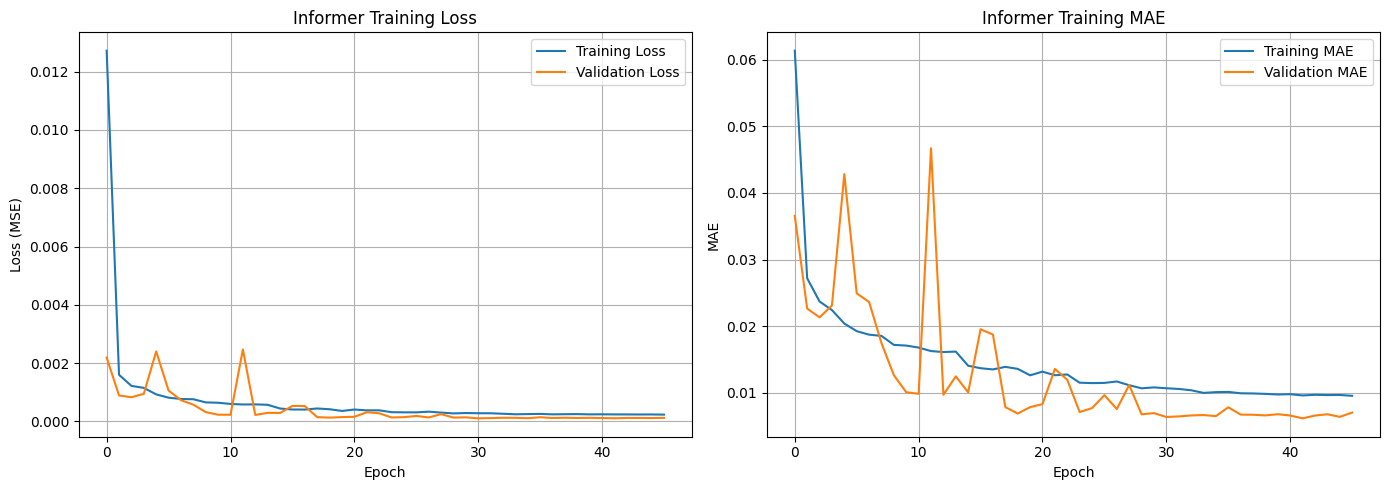

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Informer Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].legend()
axes[0].grid(True)

# MAE
axes[1].plot(history.history['mae'], label='Training MAE')
axes[1].plot(history.history['val_mae'], label='Validation MAE')
axes[1].set_title('Informer Training MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("images/informer-training-history.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

In [68]:
# Save training history
history_df = pd.DataFrame(history.history)
history_df.to_csv('training_history_informer.csv', index=False)
print('Training history saved to training_history_informer.csv')

Training history saved to training_history_informer.csv


## Predict Dataset

In [69]:
# Load best model
model = keras.models.load_model(
    'models/informer_k8s_best.keras',
    custom_objects={
        'PositionalEncoding': PositionalEncoding,
        'ProbSparseSelfAttention': ProbSparseSelfAttention,
        'ConvLayer': ConvLayer,
        'EncoderLayer': EncoderLayer,
        'DecoderLayer': DecoderLayer
    }
)
print('Loaded best model from checkpoint')

Loaded best model from checkpoint


In [70]:
pods_train_predict = model.predict(X_train_pods, verbose=0)

start_time = time.time()
pods_test_predict = model.predict(X_test_pods, verbose=0)
end_time = time.time()

prediction_time = (end_time - start_time) * 1000

print(f'POD DATASET - Prediction Size Train: {len(pods_train_predict)} | Prediction Size Test: {len(pods_test_predict)}')
print(f'Prediction Time: {prediction_time:.2f}ms')

POD DATASET - Prediction Size Train: 30223 | Prediction Size Test: 12953
Prediction Time: 3535.81ms


## Evaluate Model (Scaled Values)

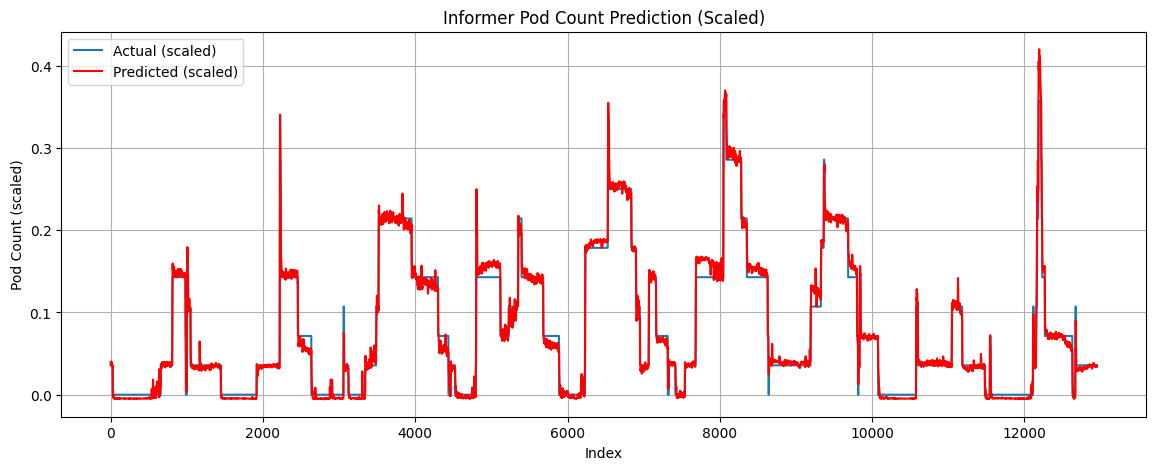

In [71]:
plt.figure(figsize=(14, 5))
plt.plot(y_test_pods, label='Actual (scaled)', color='#1f77b4')
plt.plot(pods_test_predict, label='Predicted (scaled)', color='red')
plt.xlabel('Index')
plt.ylabel('Pod Count (scaled)')
plt.title('Informer Pod Count Prediction (Scaled)')
plt.legend()
plt.grid(True)
plt.savefig("images/informer-pods-scaled-output.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

In [72]:
mse_scaled = mean_squared_error(y_test_pods, pods_test_predict)
rmse_scaled = np.sqrt(mse_scaled)
mae_scaled = mean_absolute_error(y_test_pods, pods_test_predict)
r2_scaled = r2_score(y_test_pods, pods_test_predict)

print('=== Informer Model Metrics (Scaled Values) ===')
print(f'MSE: {mse_scaled:.6f}')
print(f'RMSE: {rmse_scaled:.6f}')
print(f'MAE: {mae_scaled:.6f}')
print(f'R²: {r2_scaled:.6f}')

=== Informer Model Metrics (Scaled Values) ===
MSE: 0.000098
RMSE: 0.009881
MAE: 0.006423
R²: 0.984827


## Inverse Transform & Final Evaluation

In [73]:
# Inverse transform predictions to original scale
y_test_actual = target_scaler.inverse_transform(y_test_pods.reshape(-1, 1)).flatten()
y_test_predicted = target_scaler.inverse_transform(pods_test_predict).flatten()

# Round to nearest integer (pod count should be whole numbers)
y_test_predicted_rounded = np.round(y_test_predicted).astype(int)
y_test_predicted_rounded = np.maximum(y_test_predicted_rounded, 1)  # Minimum 1 pod

print(f'Actual pods range: {y_test_actual.min():.0f} - {y_test_actual.max():.0f}')
print(f'Predicted pods range: {y_test_predicted_rounded.min()} - {y_test_predicted_rounded.max()}')

Actual pods range: 2 - 12
Predicted pods range: 2 - 14


In [74]:
mse = mean_squared_error(y_test_actual, y_test_predicted_rounded)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_actual, y_test_predicted_rounded)
r2 = r2_score(y_test_actual, y_test_predicted_rounded)

print('=== Informer Model Metrics (Pod Count) ===')
print(f'MSE: {mse:.6f}')
print(f'RMSE: {rmse:.6f}')
print(f'MAE: {mae:.6f}')
print(f'R²: {r2:.6f}')
print(f'Prediction Time: {prediction_time:.2f}ms')

=== Informer Model Metrics (Pod Count) ===
MSE: 0.079287
RMSE: 0.281579
MAE: 0.071258
R²: 0.984283
Prediction Time: 3535.81ms


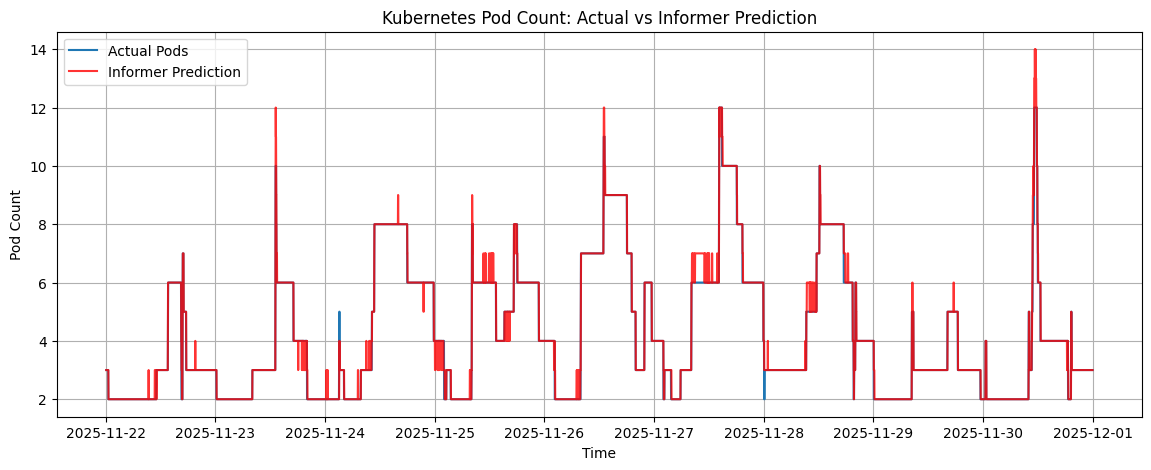

In [75]:
# Get corresponding timestamps for test set
test_timestamps = df_pods['ds'].iloc[len(X_train_pods) + look_back:len(X_train_pods) + look_back + len(y_test_pods)].values

plt.figure(figsize=(14, 5))
plt.plot(test_timestamps, y_test_actual, label='Actual Pods', color='#1f77b4', linewidth=1.5)
plt.plot(test_timestamps, y_test_predicted_rounded, label='Informer Prediction', color='red', linewidth=1.5, alpha=0.8)
plt.title('Kubernetes Pod Count: Actual vs Informer Prediction')
plt.xlabel('Time')
plt.ylabel('Pod Count')
plt.grid(True)
plt.legend()
plt.savefig("images/informer-pods-final-output.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

### Zoomed View (First 1000 samples)

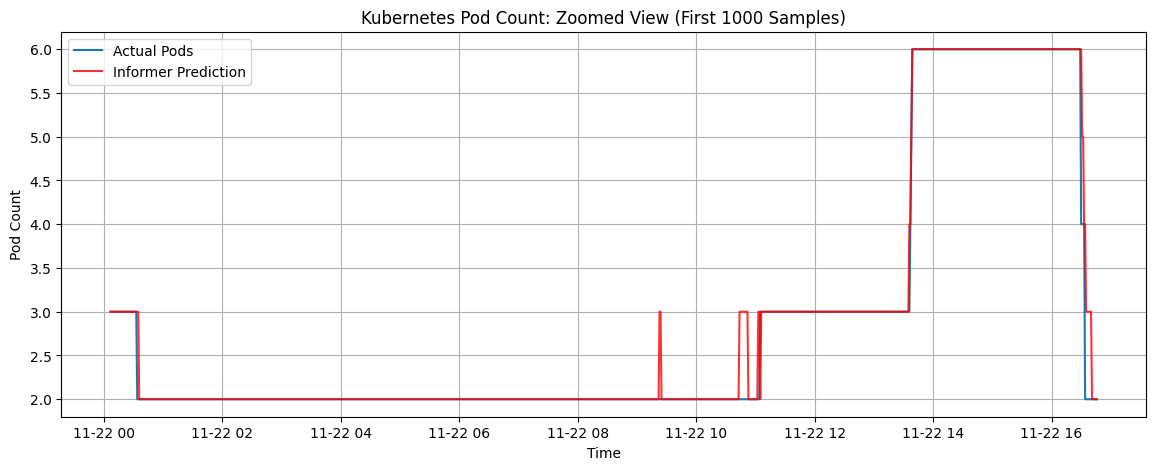

In [76]:
zoom_samples = 1000

plt.figure(figsize=(14, 5))
plt.plot(test_timestamps[:zoom_samples], y_test_actual[:zoom_samples], label='Actual Pods', color='#1f77b4', linewidth=1.5)
plt.plot(test_timestamps[:zoom_samples], y_test_predicted_rounded[:zoom_samples], label='Informer Prediction', color='red', linewidth=1.5, alpha=0.8)
plt.title('Kubernetes Pod Count: Zoomed View (First 1000 Samples)')
plt.xlabel('Time')
plt.ylabel('Pod Count')
plt.grid(True)
plt.legend()
plt.savefig("images/informer-pods-zoomed.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

## Error Analysis

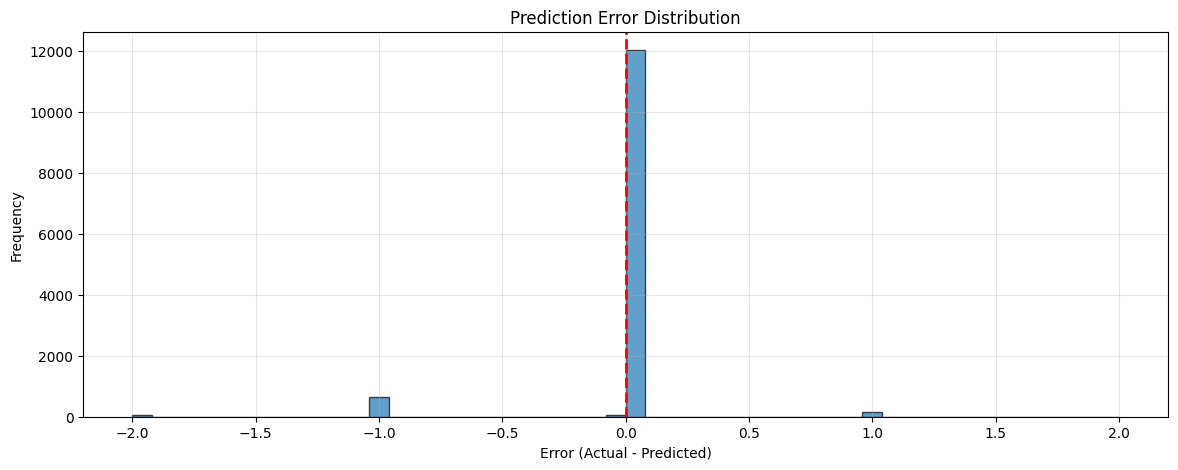

Mean Error: -0.0433
Std Error: 0.2782
Max Over-prediction: -2.0000000000000018
Max Under-prediction: 2.0


In [77]:
errors = y_test_actual - y_test_predicted_rounded

plt.figure(figsize=(14, 5))
plt.hist(errors, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.title('Prediction Error Distribution')
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.savefig("images/informer-error-distribution.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

print(f'Mean Error: {errors.mean():.4f}')
print(f'Std Error: {errors.std():.4f}')
print(f'Max Over-prediction: {errors.min()}')
print(f'Max Under-prediction: {errors.max()}')

In [78]:
# Under-provisioning and Over-provisioning analysis
under_provisioned = (y_test_predicted_rounded < y_test_actual).sum()
over_provisioned = (y_test_predicted_rounded > y_test_actual).sum()
exact_match = (y_test_predicted_rounded == y_test_actual).sum()

total = len(y_test_actual)

print('=== Provisioning Analysis ===')
print(f'Under-provisioned: {under_provisioned} ({100*under_provisioned/total:.2f}%)')
print(f'Over-provisioned: {over_provisioned} ({100*over_provisioned/total:.2f}%)')
print(f'Exact match: {exact_match} ({100*exact_match/total:.2f}%)')

=== Provisioning Analysis ===
Under-provisioned: 176 (1.36%)
Over-provisioned: 739 (5.71%)
Exact match: 12038 (92.94%)


## Autoscaling Elasticity Metrics

Compute under/over-provisioning rates and the composite elastic speed-up (εₙ) using actual pod demand vs predicted pods. Adjust `sample_interval_minutes` if each row is not one minute.

In [79]:
# Reusable helper for elasticity + raw under/over values
import numpy as np

def compute_elasticity_metrics(actual, predicted, sample_interval_minutes=1):
    """Return both normalized (%) and raw (pods / pod-minutes) provisioning metrics."""
    r_t = np.array(actual, dtype=float)
    p_t = np.array(predicted, dtype=float)

    if r_t.shape != p_t.shape:
        raise ValueError("actual and predicted must have the same shape")

    if sample_interval_minutes <= 0:
        raise ValueError("sample_interval_minutes must be positive")

    n = len(r_t)
    total_time_minutes = n * sample_interval_minutes
    if total_time_minutes <= 0:
        raise ValueError("total_time_minutes must be positive")

    under = np.maximum(r_t - p_t, 0.0)
    over = np.maximum(p_t - r_t, 0.0)

    sgn_under = (under > 0).astype(int)
    sgn_over = (over > 0).astype(int)

    # --- Raw values (pods and pod-minutes)
    total_under_pods = float(under.sum())
    total_over_pods = float(over.sum())
    mean_under_pods = float(under.mean())
    mean_over_pods = float(over.mean())
    max_under_pods = float(under.max()) if n else 0.0
    max_over_pods = float(over.max()) if n else 0.0

    minutes_under = int(sgn_under.sum() * sample_interval_minutes)
    minutes_over = int(sgn_over.sum() * sample_interval_minutes)

    # Useful "area" measure: pod-minutes (pods * minutes)
    under_pod_minutes = float((under * sample_interval_minutes).sum())
    over_pod_minutes = float((over * sample_interval_minutes).sum())

    # --- Normalized (%) metrics used by the paper-style formulas
    # NOTE: this normalizes by r_t; if r_t == 0 at any point, that ratio is undefined.
    # We ignore those points in the ratio-based sums.
    valid = r_t > 0
    r_t_valid = r_t[valid]
    under_valid = under[valid]
    over_valid = over[valid]

    theta_u = (100.0 / total_time_minutes) * float((under_valid / r_t_valid).sum())
    theta_o = (100.0 / total_time_minutes) * float((over_valid / r_t_valid).sum())
    t_u = (100.0 / total_time_minutes) * float(sgn_under.sum())
    t_o = (100.0 / total_time_minutes) * float(sgn_over.sum())

    # ε_n (elastic speed-up) is undefined/infinite if any term is exactly 0
    constant = 0.189 * 593.755 * 2.2 * 97.6
    if theta_u == 0 or theta_o == 0 or t_u == 0 or t_o == 0:
        elastic_speedup = float('inf')
    else:
        elastic_speedup = float((constant / (theta_u * theta_o * t_u * t_o)) ** 0.25)

    return {
        # normalized
        "theta_u": theta_u,
        "theta_o": theta_o,
        "t_u": t_u,
        "t_o": t_o,
        "elastic_speedup": elastic_speedup,
        # raw
        "total_under_pods": total_under_pods,
        "total_over_pods": total_over_pods,
        "mean_under_pods": mean_under_pods,
        "mean_over_pods": mean_over_pods,
        "max_under_pods": max_under_pods,
        "max_over_pods": max_over_pods,
        "minutes_under": minutes_under,
        "minutes_over": minutes_over,
        "under_pod_minutes": under_pod_minutes,
        "over_pod_minutes": over_pod_minutes,
        "total_time_minutes": total_time_minutes,
    }

# Compute metrics for Informer (actual vs rounded predictions)
metrics = compute_elasticity_metrics(
    actual=y_test_actual,
    predicted=y_test_predicted_rounded,
    sample_interval_minutes=1  # change if each row is not one minute
)

print("=== Elasticity Metrics (Informer) ===")
print(f"Θ_U (avg under %): {metrics['theta_u']:.4f}")
print(f"Θ_O (avg over %):  {metrics['theta_o']:.4f}")
print(f"T_U (time under %): {metrics['t_u']:.4f}")
print(f"T_O (time over %):  {metrics['t_o']:.4f}")
print(f"ε_n (elastic speed-up): {metrics['elastic_speedup']}")

print("\n--- Raw Under/Over (Pods) ---")
print(f"Total time (minutes): {metrics['total_time_minutes']}")
print(f"Minutes under-provisioned: {metrics['minutes_under']}")
print(f"Minutes over-provisioned:  {metrics['minutes_over']}")
print(f"Total under (pods): {metrics['total_under_pods']:.2f}")
print(f"Total over (pods):  {metrics['total_over_pods']:.2f}")
print(f"Under pod-minutes: {metrics['under_pod_minutes']:.2f}")
print(f"Over pod-minutes:  {metrics['over_pod_minutes']:.2f}")
print(f"Mean under per step (pods): {metrics['mean_under_pods']:.4f}")
print(f"Mean over per step (pods):  {metrics['mean_over_pods']:.4f}")
print(f"Max under (pods): {metrics['max_under_pods']:.2f}")
print(f"Max over (pods):  {metrics['max_over_pods']:.2f}")

=== Elasticity Metrics (Informer) ===
Θ_U (avg under %): 0.3071
Θ_O (avg over %):  1.3428
T_U (time under %): 1.3588
T_O (time over %):  5.7052
ε_n (elastic speed-up): 9.317925728341553

--- Raw Under/Over (Pods) ---
Total time (minutes): 12953
Minutes under-provisioned: 176
Minutes over-provisioned:  739
Total under (pods): 181.00
Total over (pods):  742.00
Under pod-minutes: 181.00
Over pod-minutes:  742.00
Mean under per step (pods): 0.0140
Mean over per step (pods):  0.0573
Max under (pods): 2.00
Max over (pods):  2.00


## Attention Visualization (Optional)

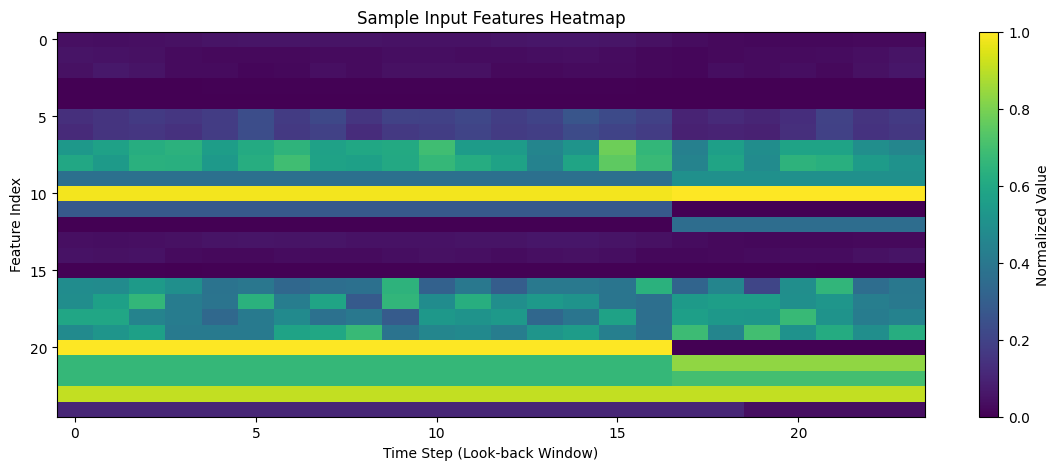

In [80]:
# Visualize input importance over time window
sample_idx = 0
sample_input = X_test_pods[sample_idx:sample_idx+1]

plt.figure(figsize=(14, 5))
plt.imshow(sample_input[0].T, aspect='auto', cmap='viridis')
plt.colorbar(label='Normalized Value')
plt.xlabel('Time Step (Look-back Window)')
plt.ylabel('Feature Index')
plt.title('Sample Input Features Heatmap')
plt.savefig("images/informer-input-heatmap.jpeg", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

## Save Model

In [81]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save model
model_filename = f'models/informer-pods-{timestamp}.keras'
model.save(model_filename)
print(f'Model saved: {model_filename}')

# Save scalers
import joblib
scaler_filename = f'models/informer-scalers-{timestamp}.pkl'
joblib.dump({'target_scaler': target_scaler, 'feature_scaler': feature_scaler}, scaler_filename)
print(f'Scalers saved: {scaler_filename}')

Model saved: models/informer-pods-20260103_181557.keras
Scalers saved: models/informer-scalers-20260103_181557.pkl


## Summary

In [82]:
print('=' * 60)
print('INFORMER MODEL SUMMARY')
print('=' * 60)
print(f'Dataset: data.csv ({primary_service})')
print(f'Total samples: {len(df_pods)}')
print(f'Features: {num_features} (multivariate + time features)')
print(f'Look-back window: {look_back}')
print(f'Train/Test split: 70/30')
print('-' * 60)
print('MODEL CONFIGURATION')
print('-' * 60)
print(f'd_model: {D_MODEL}')
print(f'n_heads: {N_HEADS}')
print(f'encoder_layers: {E_LAYERS}')
print(f'decoder_layers: {D_LAYERS}')
print(f'd_ff: {D_FF}')
print('-' * 60)
print('METRICS (Pod Count)')
print('-' * 60)
print(f'MSE: {mse:.6f}')
print(f'RMSE: {rmse:.6f}')
print(f'MAE: {mae:.6f}')
print(f'R²: {r2:.6f}')
print('-' * 60)
print('PROVISIONING')
print('-' * 60)
print(f'Under-provisioned: {100*under_provisioned/total:.2f}%')
print(f'Over-provisioned: {100*over_provisioned/total:.2f}%')
print(f'Exact match: {100*exact_match/total:.2f}%')
print('-' * 60)
print(f'Prediction Time: {prediction_time:.2f}ms')
print('=' * 60)

INFORMER MODEL SUMMARY
Dataset: data.csv (Order)
Total samples: 43200
Features: 25 (multivariate + time features)
Look-back window: 24
Train/Test split: 70/30
------------------------------------------------------------
MODEL CONFIGURATION
------------------------------------------------------------
d_model: 64
n_heads: 4
encoder_layers: 2
decoder_layers: 1
d_ff: 256
------------------------------------------------------------
METRICS (Pod Count)
------------------------------------------------------------
MSE: 0.079287
RMSE: 0.281579
MAE: 0.071258
R²: 0.984283
------------------------------------------------------------
PROVISIONING
------------------------------------------------------------
Under-provisioned: 1.36%
Over-provisioned: 5.71%
Exact match: 92.94%
------------------------------------------------------------
Prediction Time: 3535.81ms
